# Species Occurrence Data Exploration

This notebook explores the geodataframe stored in the parquet file to understand:
- Data structure and schema
- Geographical distribution
- Species information
- Feature availability
- Data quality and completeness

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

%matplotlib inline

## 1. Load Data

In [3]:
import os
from pathlib import Path


# Get the script directory and set the data path relative to it
script_dir = Path.cwd()
data_path = script_dir / '..' / 'outputs' / 'global_350km_ee_gbif.parquet'

print(f"Loading data from: {data_path}")
gdf = gpd.read_parquet(data_path)
print("Data loaded successfully!")
print(f"Shape: {gdf.shape}")

Loading data from: c:\Entwicklung\BirdNET\geomodel\notebooks\..\outputs\global_350km_ee_gbif.parquet
Data loaded successfully!
Shape: (5794, 59)


## 2. Basic Data Information

In [4]:
# Display basic information
print("=" * 80)
print("DATAFRAME INFO")
print("=" * 80)
gdf.info()

DATAFRAME INFO
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5794 entries, 0 to 5793
Data columns (total 59 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   h3_index          5794 non-null   str     
 1   geometry          5794 non-null   geometry
 2   water_fraction    231 non-null    float64 
 3   elevation_m       1838 non-null   float64 
 4   precipitation_mm  1520 non-null   float64 
 5   temperature_c     1520 non-null   float64 
 6   urban_fraction    4534 non-null   float64 
 7   landcover_class   4135 non-null   float64 
 8   canopy_height_m   5794 non-null   float64 
 9   target_km         5794 non-null   int64   
 10  h3_resolution     5794 non-null   int64   
 11  week_1            5794 non-null   object  
 12  week_2            5794 non-null   object  
 13  week_3            5794 non-null   object  
 14  week_4            5794 non-null   object  
 15  week_5            5794 non-null   object  
 16  w

In [20]:
# Display first few rows
print("\n" + "=" * 80)
print("Random 5 ROWS")
print("=" * 80)
gdf.sample(5)


Random 5 ROWS


,h3_index,geometry,water_fraction,elevation_m,precipitation_mm,temperature_c,urban_fraction,landcover_class,canopy_height_m,target_km,...,week_39,week_40,week_41,week_42,week_43,week_44,week_45,week_46,week_47,week_48
1993,825407fffffffff,"POLYGON ((-13.32045 18.32002, -14.86695 17.466...",NaN,67.0,212.0,29.4,0.000617,16.0,0.0,350,...,[],[],[],[],[],[],[],[],[],[]
1258,823567fffffffff,"POLYGON ((-14.35134 41.82241, -16.38767 40.984...",NaN,NaN,NaN,NaN,0.000000,NaN,0.0,350,...,[],[],[],[],[],[],[],[],[],[]
2802,8275b7fffffffff,"POLYGON ((-10.88398 9.21108, -12.27943 8.4363,...",NaN,235.0,2620.0,25.8,0.038374,8.0,21.0,350,...,[],[],[],[],[],[],[],[],[],[10698146]
5537,82e857fffffffff,"POLYGON ((-85.19691 -60.67735, -82.70942 -59.5...",NaN,NaN,NaN,NaN,0.000000,17.0,0.0,350,...,[],[],[],[],[],[],[],[],[],[]
2977,827cf7fffffffff,"POLYGON ((-19.42155 2.98505, -18.29182 3.99607...",NaN,NaN,NaN,NaN,0.000000,17.0,0.0,350,...,[],[],[],[],[],[],[],[],[],[]


In [6]:
# Column names and types
print("\n" + "=" * 80)
print("COLUMN SUMMARY")
print("=" * 80)
for col in gdf.columns:
    print(f"{col:30s} | {str(gdf[col].dtype):15s} | Nulls: {gdf[col].isnull().sum():6d}")


COLUMN SUMMARY
h3_index                       | str             | Nulls:      0
geometry                       | geometry        | Nulls:      0
water_fraction                 | float64         | Nulls:   5563
elevation_m                    | float64         | Nulls:   3956
precipitation_mm               | float64         | Nulls:   4274
temperature_c                  | float64         | Nulls:   4274
urban_fraction                 | float64         | Nulls:   1260
landcover_class                | float64         | Nulls:   1659
canopy_height_m                | float64         | Nulls:      0
target_km                      | int64           | Nulls:      0
h3_resolution                  | int64           | Nulls:      0
week_1                         | object          | Nulls:      0
week_2                         | object          | Nulls:      0
week_3                         | object          | Nulls:      0
week_4                         | object          | Nulls:      0
week_5   

In [7]:
# Statistical summary
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
gdf.describe()


STATISTICAL SUMMARY


,water_fraction,elevation_m,precipitation_mm,temperature_c,urban_fraction,landcover_class,canopy_height_m,target_km,h3_resolution
count,231.000000,1838.000000,1520.000000,1520.000000,4534.000000,4135.000000,5794.000000,5794.0,5794.0
mean,0.879654,531.844396,790.252632,13.107763,0.006168,14.201935,2.143252,350.0,2.0
std,0.252783,815.902412,750.624815,13.037396,0.024629,4.367780,6.477612,0.0,0.0
min,0.000000,-29.000000,0.000000,-25.600000,0.000000,1.000000,0.000000,350.0,2.0
25%,0.930000,46.000000,264.750000,2.900000,0.000000,10.000000,0.000000,350.0,2.0
50%,0.980000,263.000000,546.500000,17.050000,0.000000,17.000000,0.000000,350.0,2.0
75%,0.990000,646.500000,1099.500000,24.800000,0.000655,17.000000,0.000000,350.0,2.0
max,1.000000,6012.000000,7450.000000,30.700000,0.561078,17.000000,43.000000,350.0,2.0


## 3. Geometry and Spatial Information

In [8]:
# Geometry information
print("Coordinate Reference System (CRS):", gdf.crs)
print("\nGeometry types:")
print(gdf.geometry.geom_type.value_counts())

# Bounding box
print("\nBounding Box:")
print(f"  Min Longitude: {gdf.total_bounds[0]:.6f}")
print(f"  Min Latitude:  {gdf.total_bounds[1]:.6f}")
print(f"  Max Longitude: {gdf.total_bounds[2]:.6f}")
print(f"  Max Latitude:  {gdf.total_bounds[3]:.6f}")

Coordinate Reference System (CRS): {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum": {"type": "GeodeticReferenceFrame", "name": "World Geodetic System 1984", "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "scope": "Horizontal component of 3D system.", "area": "World.", "bbox": {"south_latitude": -90, "west_longitude": -180, "north_latitude": 90, "east_longitude": 180}, "id": {"authority": "EPSG", "code": 4326}}

Geometry types:
Polygon    5794
Name: count, dtype: int64

Bounding Box:
  Min Longitude: -179.914165
  Min Latitude:  -89.074149
  Max Longitude: 179.982924
  Max Latitude:  89.074149


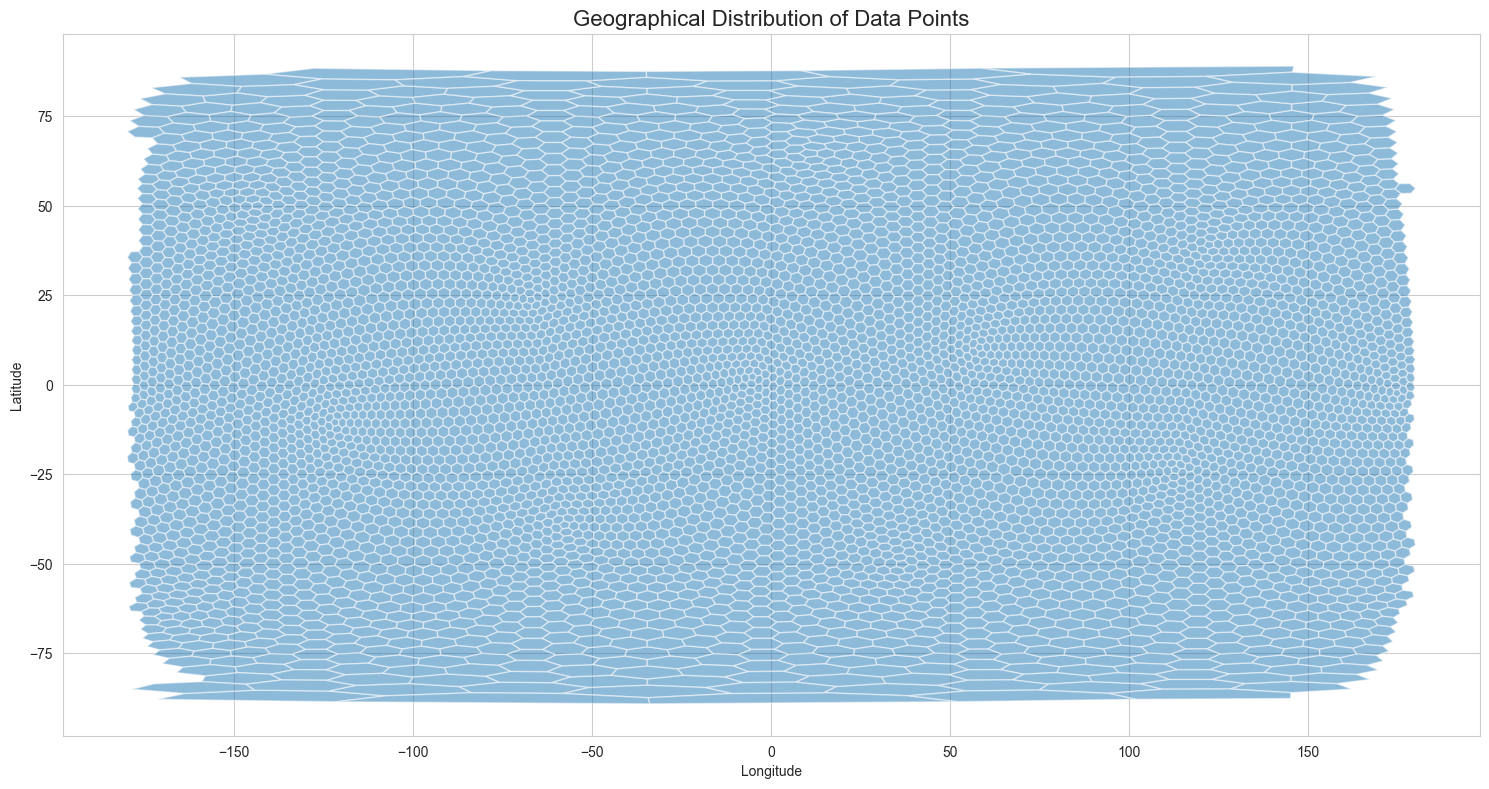

In [9]:
# Plot geographical distribution
fig, ax = plt.subplots(figsize=(15, 10))
gdf.plot(ax=ax, markersize=1, alpha=0.5)
ax.set_title('Geographical Distribution of Data Points', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 4. Species Information

In [10]:
# Identify species-related columns
species_cols = [col for col in gdf.columns if 'species' in col.lower() or 'bird' in col.lower() or 'label' in col.lower()]
print(f"Potential species columns: {species_cols}")

# If there's a species column, analyze it
if species_cols:
    species_col = species_cols[0]
    print(f"\nAnalyzing column: {species_col}")
    print(f"Number of unique species: {gdf[species_col].nunique()}")
    print(f"\nTop 10 most common species:")
    print(gdf[species_col].value_counts().head(10))
else:
    print("\nNo obvious species column found. All columns:")
    print(gdf.columns.tolist())

Potential species columns: []

No obvious species column found. All columns:
['h3_index', 'geometry', 'water_fraction', 'elevation_m', 'precipitation_mm', 'temperature_c', 'urban_fraction', 'landcover_class', 'canopy_height_m', 'target_km', 'h3_resolution', 'week_1', 'week_2', 'week_3', 'week_4', 'week_5', 'week_6', 'week_7', 'week_8', 'week_9', 'week_10', 'week_11', 'week_12', 'week_13', 'week_14', 'week_15', 'week_16', 'week_17', 'week_18', 'week_19', 'week_20', 'week_21', 'week_22', 'week_23', 'week_24', 'week_25', 'week_26', 'week_27', 'week_28', 'week_29', 'week_30', 'week_31', 'week_32', 'week_33', 'week_34', 'week_35', 'week_36', 'week_37', 'week_38', 'week_39', 'week_40', 'week_41', 'week_42', 'week_43', 'week_44', 'week_45', 'week_46', 'week_47', 'week_48']


In [11]:
# If species column exists, plot distribution
if species_cols:
    species_col = species_cols[0]
    top_species = gdf[species_col].value_counts().head(20)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    top_species.plot(kind='barh', ax=ax)
    ax.set_title('Top 20 Most Common Species', fontsize=14)
    ax.set_xlabel('Count')
    ax.set_ylabel('Species')
    plt.tight_layout()
    plt.show()

## 5. Feature Analysis

In [12]:
# Identify numeric features (excluding geometry)
numeric_cols = gdf.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  - {col}")

Numeric features (9):
  - water_fraction
  - elevation_m
  - precipitation_mm
  - temperature_c
  - urban_fraction
  - landcover_class
  - canopy_height_m
  - target_km
  - h3_resolution


In [13]:
# Identify categorical features
categorical_cols = gdf.select_dtypes(include=['object', 'category']).columns.tolist()
# Remove geometry if present
categorical_cols = [col for col in categorical_cols if col != 'geometry' and not col.startswith('week')]

print(f"\nCategorical features ({len(categorical_cols)}):")
for col in categorical_cols:
    unique_count = gdf[col].nunique()
    print(f"  - {col:30s} ({unique_count} unique values)")


Categorical features (1):
  - h3_index                       (5794 unique values)


C:\Users\Max Mauermann\AppData\Local\Temp\ipykernel_18656\2818033598.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = gdf.select_dtypes(include=['object', 'category']).columns.tolist()


## 6. Data Quality Assessment

In [14]:
# Missing values
missing = gdf.isnull().sum()
missing_pct = (missing / len(gdf)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values Summary:")
if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("No missing values found!")

Missing Values Summary:
          Column  Missing Count  Missing %
  water_fraction           5563  96.013117
precipitation_mm           4274  73.765965
   temperature_c           4274  73.765965
     elevation_m           3956  68.277528
 landcover_class           1659  28.633069
  urban_fraction           1260  21.746634


## 7. Data Structure Summary for Model Training

In [16]:
# Create summary of data structure
summary = {
    'total_rows': len(gdf),
    'total_columns': len(gdf.columns),
    'geometry_type': gdf.geometry.geom_type.unique().tolist(),
    'crs': str(gdf.crs),
    'numeric_features': numeric_cols,
    'categorical_features': categorical_cols,
    'potential_target_columns': species_cols,
    'has_missing_values': missing.sum() > 0
}

print("\n" + "=" * 80)
print("DATA STRUCTURE SUMMARY FOR MODEL TRAINING")
print("=" * 80)
for key, value in summary.items():
    print(f"{key}: {value}")


DATA STRUCTURE SUMMARY FOR MODEL TRAINING
total_rows: 5794
total_columns: 59
geometry_type: ['Polygon']
crs: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum": {"type": "GeodeticReferenceFrame", "name": "World Geodetic System 1984", "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "scope": "Horizontal component of 3D system.", "area": "World.", "bbox": {"south_latitude": -90, "west_longitude": -180, "north_latitude": 90, "east_longitude": 180}, "id": {"authority": "EPSG", "code": 4326}}
numeric_features: ['water_fraction', 'elevation_m', 'precipitation_mm', 'temperature_c', 'urban_fraction', 'landcover_class', 'canopy_height_m'

In [18]:
# Save summary to file
import json

output_dir = Path('../outputs')
output_dir.mkdir(parents=True, exist_ok=True)

# Convert to JSON-serializable format
summary_json = {k: str(v) if not isinstance(v, (list, bool, int, str)) else v 
                for k, v in summary.items()}

with open(output_dir / 'data_summary.json', 'w') as f:
    json.dump(summary_json, f, indent=2)

print(f"\nData summary saved to: {output_dir / 'data_summary.json'}")


Data summary saved to: ..\outputs\data_summary.json
